# **Snitch Fashion Sales**
📌 Context:
below used is a synthetic dataset representing sales transactions from Snitch, a fictional Indian clothing brand. The dataset simulates real-world retail sales data with uncleaned records, designed for learners and professionals to practice data cleaning, exploratory data analysis (EDA)




Columns Explained
Column --Description
Order_ID ------Unique ID for each sale (some duplicates)
Customer_Name ------Name of the customer (inconsistent formatting)
Product_Category ---Clothing category (e.g., T-Shirts, Jeans — includes typos)
Product_Name -----Specific product sold
Units_Sold --Quantity sold (some negative or null)
Unit_Price --Price per unit (some missing or zero)
Discount_% ----Discount applied (some >100% or missing)
Sales_Amount ------Total revenue after discount (some miscalculations)
Order_Date ---------Order date (multiple formats or missing)
City -------Indian city (includes typos like "Hyd", "bengaluru")
Segment----- Market segment (B2C, B2B, or missing)
Profit ---------Profit made on the sale (some unrealistic/negative)



# PROBLEM STATEMENT:
Finding Top-selling categories

Impact of discounts on sales and profits

Analysing Revenue & Profit by City

Monthly/quarterly trends

Segment-based performance

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Snitch_Fashion_Sales_Uncleaned.csv to Snitch_Fashion_Sales_Uncleaned.csv


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('Snitch_Fashion_Sales_Uncleaned.csv')
print(df.shape)
print(df.isnull().sum())

(2500, 12)
Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64


In [6]:
#  Standardize City Names
city_map = {
    'bengaluru': 'Bangalore',
    'hyderbad': 'Hyderabad',
    'Hyd': 'Hyderabad',
}
df['City'] = df['City'].replace(city_map)

In [7]:
#  Fix Mixed Date Formats
def parse_date(d):
    if pd.isnull(d):
        return pd.NaT
    for fmt in ('%Y-%m-%d', '%d-%m-%Y', '%Y/%m/%d', '%m/%d/%Y'):
        try:
            return pd.to_datetime(d, format=fmt)
        except:
            pass
    return pd.NaT

df['Order_Date'] = df['Order_Date'].apply(parse_date)

# Fill missing dates with median
median_date = df['Order_Date'].dropna().sort_values().iloc[len(df['Order_Date'].dropna()) // 2]
df['Order_Date'] = df['Order_Date'].fillna(median_date)

In [9]:
#  Fill Missing Segment
df['Segment'] = df['Segment'].fillna(df['Segment'].mode()[0])

In [10]:
#  Fill Missing Discount_%
df['Discount_%'] = df['Discount_%'].fillna(0)

In [11]:
# Impute Missing Unit_Price
def fill_unit_price(row):
    if pd.notnull(row['Unit_Price']):
        return row['Unit_Price']
    if pd.notnull(row['Units_Sold']) and row['Units_Sold'] > 0 and row['Sales_Amount'] != 0:
        discount = row['Discount_%'] if pd.notnull(row['Discount_%']) else 0
        factor = (1 - discount) if discount < 1 else 1
        if factor > 0:
            return row['Sales_Amount'] / (row['Units_Sold'] * factor)
    return row['Unit_Price']

df['Unit_Price'] = df.apply(fill_unit_price, axis=1)

# Fill remaining with category median
df['Unit_Price'] = df.groupby('Product_Category')['Unit_Price'].transform(
    lambda x: x.fillna(x.median())
)

In [12]:
# Fix Negative & Missing Units_Sold # Replace negatives with NaN
df.loc[df['Units_Sold'] < 0, 'Units_Sold'] = np.nan

# Impute with category median
df['Units_Sold'] = df.groupby('Product_Category')['Units_Sold'].transform(
    lambda x: x.fillna(x.median())
)

# Fallback: overall median for any remaining
df['Units_Sold'] = df['Units_Sold'].fillna(df['Units_Sold'].median())

# Convert to integer
df['Units_Sold'] = df['Units_Sold'].round(0).astype(int)

In [13]:
#  Round Numeric Columns
for col in ['Unit_Price', 'Discount_%', 'Sales_Amount', 'Profit']:
    df[col] = df[col].round(2)

In [14]:
#  Verify & Save
print("Remaining nulls:")
print(df.isnull().sum())

df.to_csv('Snitch_Fashion_Sales_Cleaned.csv', index=False)
print("Done!")

Remaining nulls:
Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
dtype: int64
Done!


In [15]:
# EDA
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Scikit-learn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
np.random.seed(42)
tf.random.set_seed(42)

print('Libraries loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded successfully!
TensorFlow version: 2.19.0


In [16]:
df = pd.read_csv('Snitch_Fashion_Sales_Cleaned.csv', parse_dates=['Order_Date'])

# Extract time features
df['Month']   = df['Order_Date'].dt.month
df['Year']    = df['Order_Date'].dt.year
df['Quarter'] = df['Order_Date'].dt.quarter

print('Shape:', df.shape)
df.head()

Shape: (2500, 15)


,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit,Month,Year,Quarter
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,3,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45,2,2025,1
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1,2705.09,0.00,0.00,2025-07-15,Ahmedabad,B2B,1588.15,7,2025,3
2,1002,Sarah Snyder,Jackets,Puffer Coat,1,637.82,0.00,0.00,2025-01-02,Mumbai,B2B,-158.03,1,2025,1
3,1003,Jay Briggs,Shoes,Loafers,2,2962.27,0.00,0.00,2025-06-18,Bangalore,B2B,2296.50,6,2025,2
4,1004,Maria Blake,Accessories,Belts,1,2881.07,0.27,2103.18,2024-12-21,Hyderabad,B2B,63.66,12,2024,4


In [17]:
print('=== Dataset Info ===')
df.info()
print()
print('=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2500 non-null   int64         
 1   Customer_Name     2500 non-null   object        
 2   Product_Category  2500 non-null   object        
 3   Product_Name      2500 non-null   object        
 4   Units_Sold        2500 non-null   int64         
 5   Unit_Price        2500 non-null   float64       
 6   Discount_%        2500 non-null   float64       
 7   Sales_Amount      2500 non-null   float64       
 8   Order_Date        2500 non-null   datetime64[ns]
 9   City              2500 non-null   object        
 10  Segment           2500 non-null   object        
 11  Profit            2500 non-null   float64       
 12  Month             2500 non-null   int32         
 13  Year              2500 non-null   int32         
 14  Qua

,Order_ID,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,Profit,Month,Year,Quarter
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500,2500.00,2500.00,2500.00,2500.00
mean,2193.06,3.00,2677.97,0.22,126.76,2024-11-28 15:26:47.040000256,981.57,7.80,2024.30,2.85
min,1000.00,0.00,400.21,0.00,-7518.33,2023-07-23 00:00:00,-992.61,1.00,2023.00,1.00
25%,1543.75,3.00,2551.67,0.00,0.00,2024-10-02 00:00:00,-19.67,4.00,2024.00,2.00
50%,2182.50,3.00,2670.64,0.00,0.00,2024-12-21 00:00:00,947.88,8.00,2024.00,3.00
75%,2842.25,3.00,2899.92,0.33,0.00,2025-03-03 00:00:00,1993.52,12.00,2025.00,4.00
max,3499.00,6.00,4998.91,1.30,29180.68,2025-07-22 00:00:00,2997.11,12.00,2025.00,4.00
std,748.06,1.22,952.49,0.38,1464.94,NaN,1159.16,3.83,0.57,1.17


In [18]:
print('Missing Values:')
print(df.isnull().sum())
print()
print('Duplicate Rows:', df.duplicated().sum())

Missing Values:
Order_ID            0
Customer_Name       0
Product_Category    0
Product_Name        0
Units_Sold          0
Unit_Price          0
Discount_%          0
Sales_Amount        0
Order_Date          0
City                0
Segment             0
Profit              0
Month               0
Year                0
Quarter             0
dtype: int64

Duplicate Rows: 0


In [19]:
# Revenue & Profit Summary
total_revenue = df['Sales_Amount'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order_ID'].nunique()
avg_discount  = df['Discount_%'].mean()

print(f'Total Revenue  : ₹{total_revenue:,.2f}')
print(f'Total Profit   : ₹{total_profit:,.2f}')
print(f'Total Orders   : {total_orders}')
print(f'Avg Discount   : {avg_discount:.2%}')
print(f'Profit Margin  : {(total_profit/total_revenue)*100:.1f}%' if total_revenue != 0 else 'N/A')

Total Revenue  : ₹316,890.63
Total Profit   : ₹2,453,922.58
Total Orders   : 2391
Avg Discount   : 21.95%
Profit Margin  : 774.4%


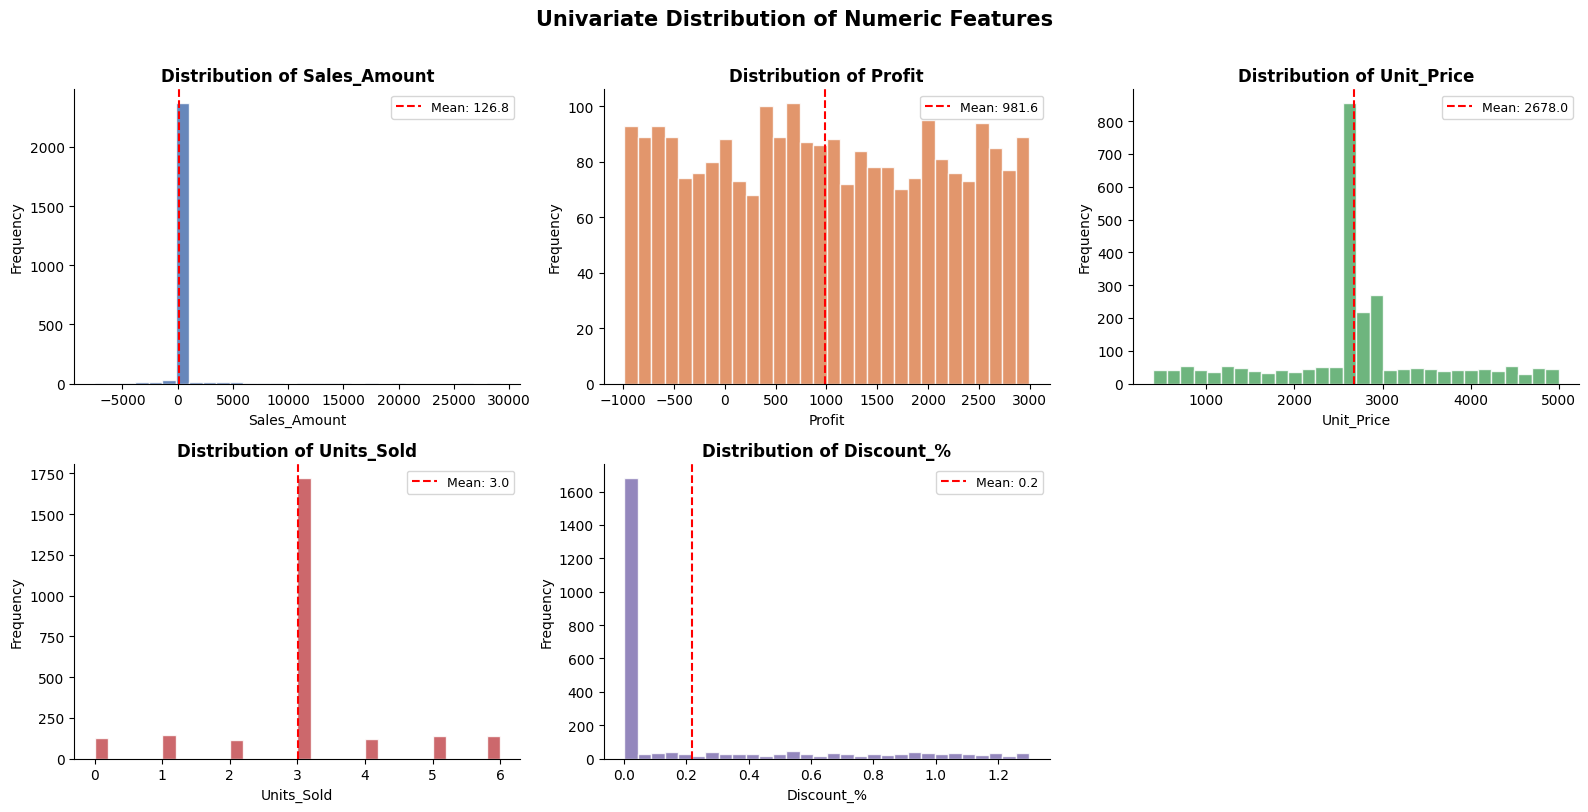

In [20]:
num_cols = ['Sales_Amount', 'Profit', 'Unit_Price', 'Units_Sold', 'Discount_%']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Univariate Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

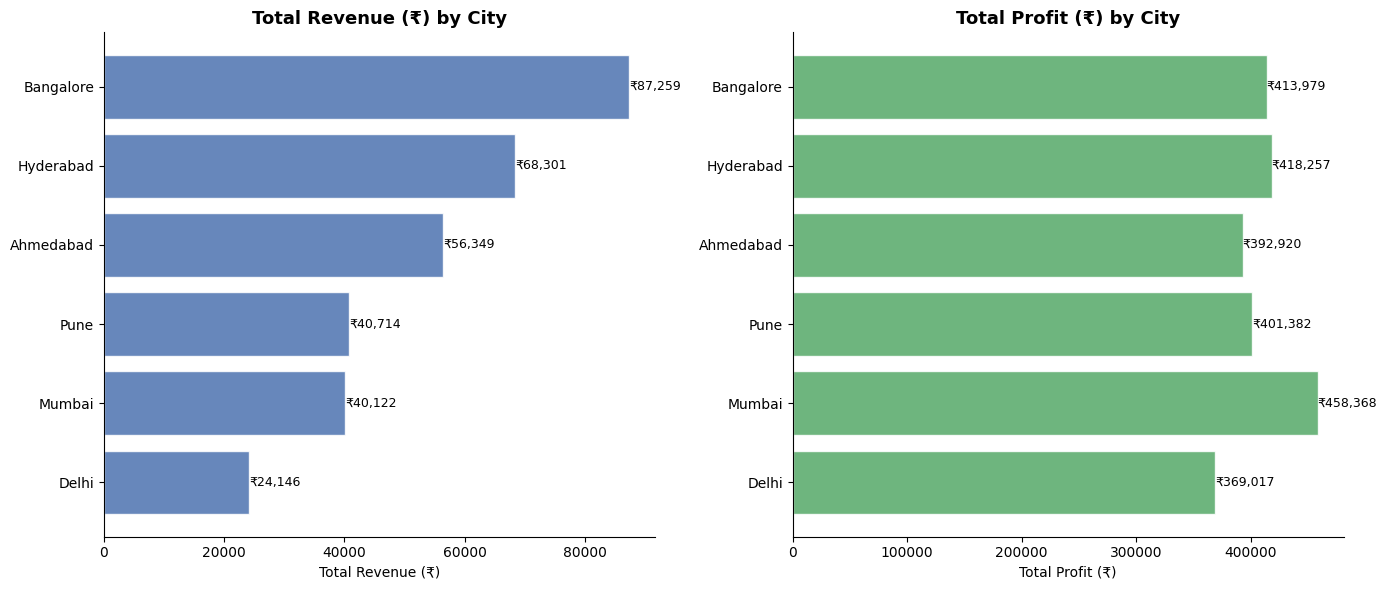

In [22]:
# 4.2 Revenue & Profit by City
city_perf = df.groupby('City').agg(
    Total_Revenue=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
).sort_values('Total_Revenue', ascending=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, color, label in zip(
    axes,
    ['Total_Revenue', 'Total_Profit'],
    ['#4C72B0', '#55A868'],
    ['Total Revenue (₹)', 'Total Profit (₹)']
):
    bars = ax.barh(city_perf['City'], city_perf[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{label} by City', fontsize=13, fontweight='bold')
    ax.set_xlabel(label)
    for bar in bars:
        ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'₹{bar.get_width():,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

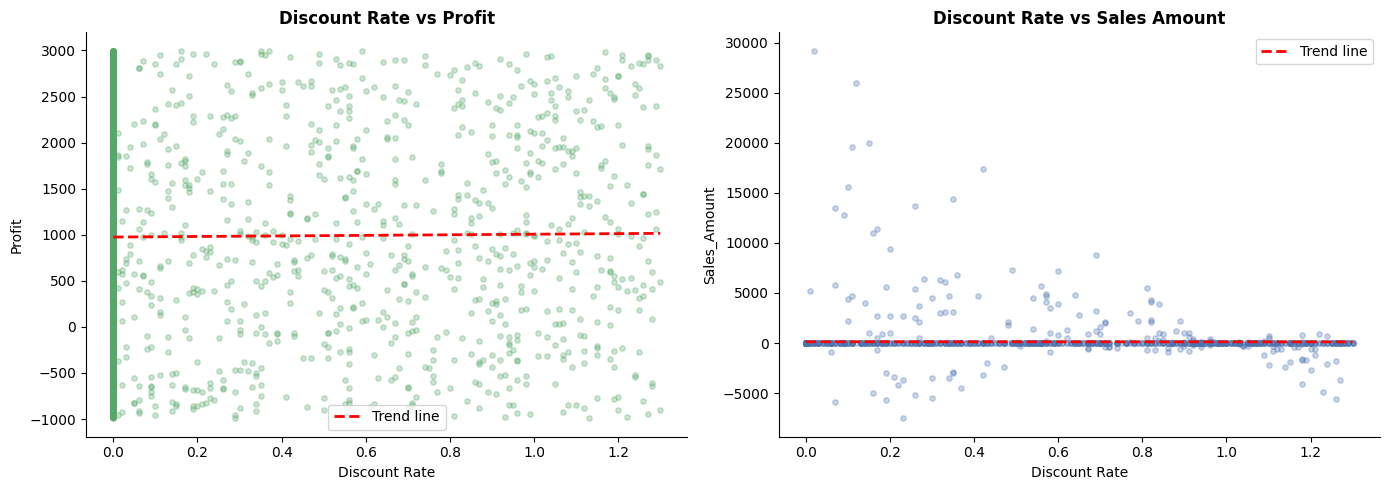

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_col, color, title in zip(
    axes,
    ['Profit', 'Sales_Amount'],
    ['#55A868', '#4C72B0'],
    ['Discount Rate vs Profit', 'Discount Rate vs Sales Amount']
):
    ax.scatter(df['Discount_%'], df[y_col], alpha=0.3, color=color, s=15)
    # Trend line using numpy
    mask = df[['Discount_%', y_col]].dropna()
    z = np.polyfit(mask['Discount_%'], mask[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mask['Discount_%'].min(), mask['Discount_%'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
    ax.set_xlabel('Discount Rate')
    ax.set_ylabel(y_col)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

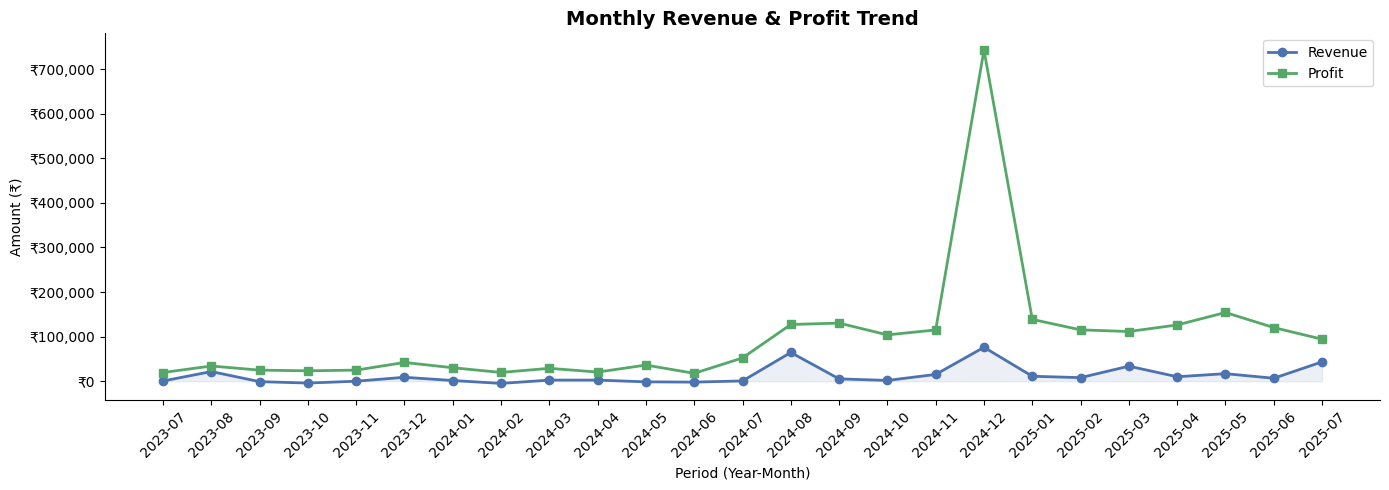

In [26]:
monthly = df.groupby(['Year', 'Month']).agg(
    Revenue=('Sales_Amount', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly = monthly.sort_values('Period')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Revenue'], marker='o', color='#4C72B0', linewidth=2, label='Revenue')
ax.plot(monthly['Period'], monthly['Profit'],  marker='s', color='#55A868', linewidth=2, label='Profit')
ax.fill_between(monthly['Period'], monthly['Revenue'], alpha=0.1, color='#4C72B0')
ax.set_title('Monthly Revenue & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period (Year-Month)')
ax.set_ylabel('Amount (₹)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'₹{val:,.0f}'))
plt.tight_layout()
plt.show()

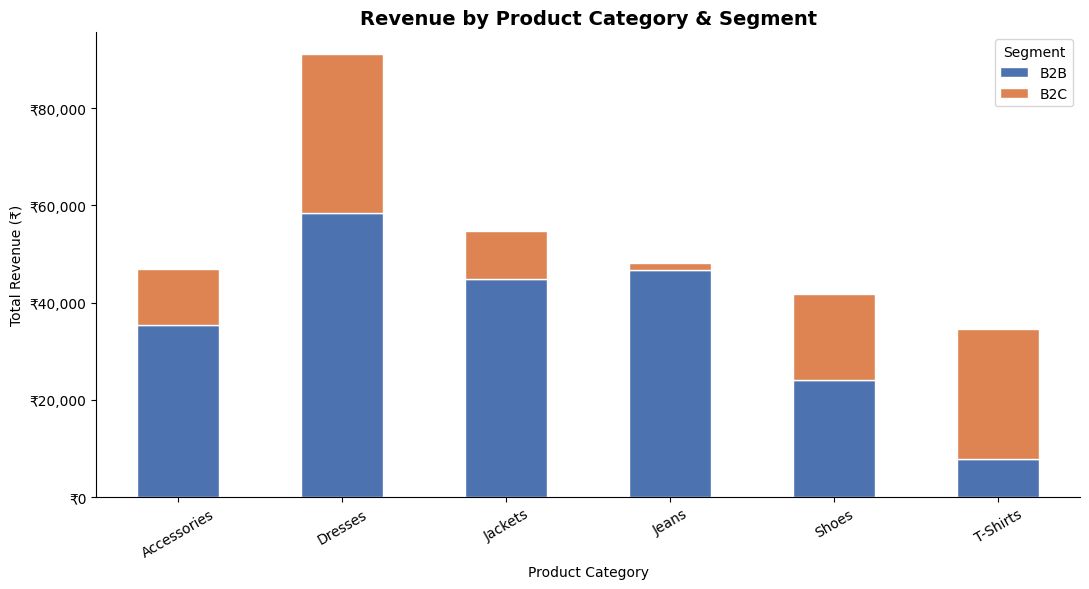

In [43]:
### 5.2 Revenue by Segment & Category (Stacked Bar)
pivot2 = df.pivot_table(values='Sales_Amount', index='Product_Category', columns='Segment', aggfunc='sum').fillna(0)

pivot2.plot(kind='bar', stacked=True, figsize=(11, 6), color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
plt.title('Revenue by Product Category & Segment', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30)
plt.legend(title='Segment')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'₹{val:,.0f}'))
plt.tight_layout()
plt.show()

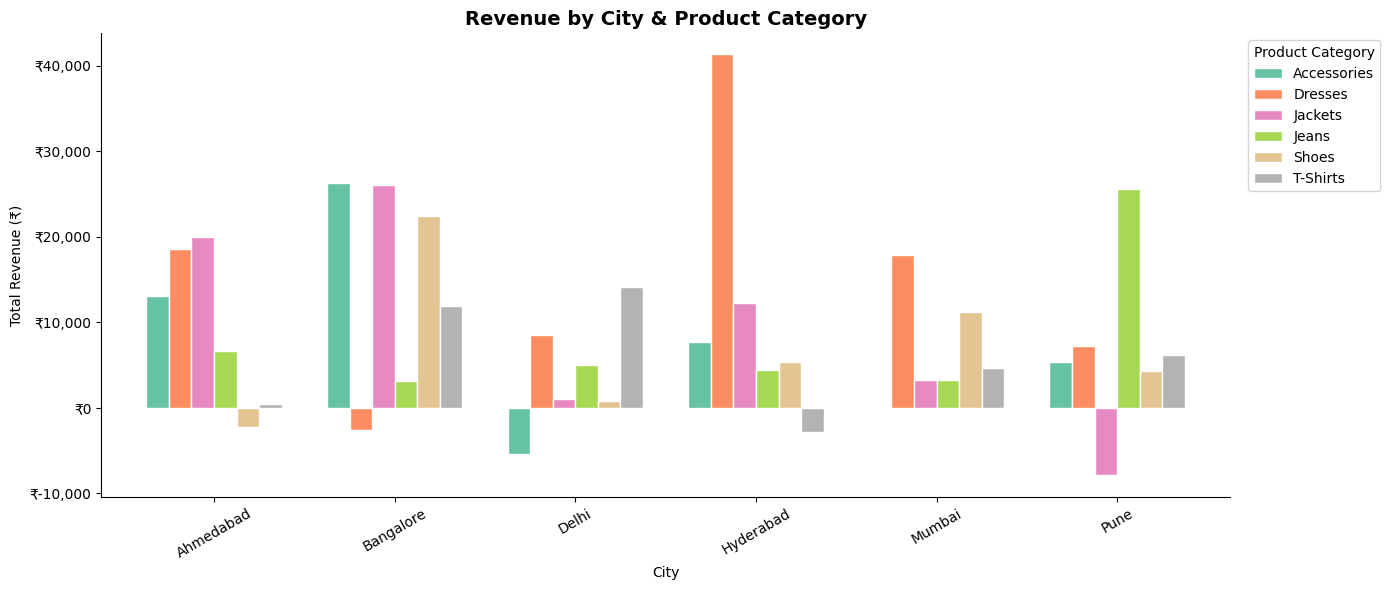

In [31]:
# 5. Multivariate & Interaction Analysis
# 5.1 Revenue by Category & City (Grouped Bar)
pivot = df.pivot_table(values='Sales_Amount', index='City', columns='Product_Category', aggfunc='sum').fillna(0)

pivot.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='white', width=0.75)
plt.title('Revenue by City & Product Category', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30)
plt.legend(title='Product Category', bbox_to_anchor=(1.01, 1))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'₹{val:,.0f}'))
plt.tight_layout()
plt.show()

scikit-learn

In [33]:

## 7. Feature Importance using Scikit-learn (Random Forest)
### 7.1 Encode Features & Prepare Datafeatures = ['Product_Category', 'City', 'Segment', 'Units_Sold', 'Unit_Price', 'Discount_%', 'Month', 'Quarter']
target   = 'Profit'

df_model = df[features + [target]].copy()

# Label encode categoricals
le = LabelEncoder()
for col in ['Product_Category', 'City', 'Segment']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (2000, 8), Test: (500, 8)


Random Forest → RMSE: 1236.03 | R²: -0.1547


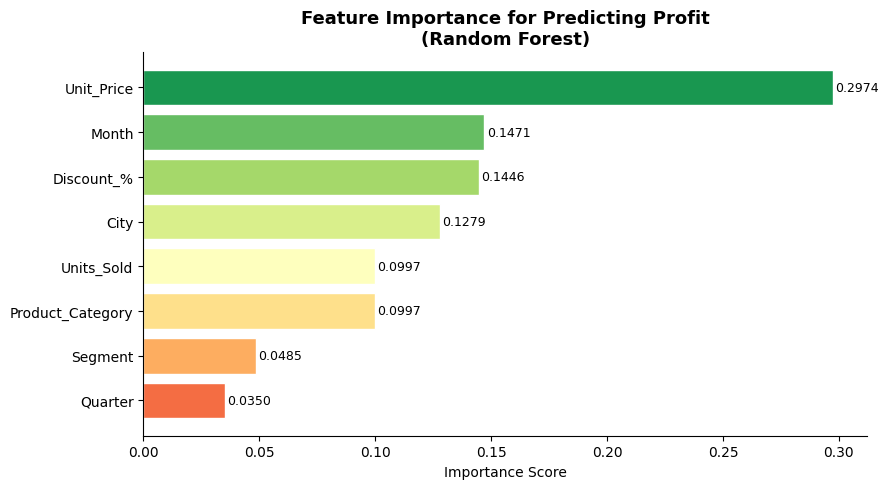

In [35]:
# random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print(f'Random Forest → RMSE: {rmse_rf:.2f} | R²: {r2_rf:.4f}')

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_title('Feature Importance for Predicting Profit\n(Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

compare ML models

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, round(rmse, 2), round(r2, 4)])

# Create and display result table
results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])
print(results_df)

               Model    RMSE  R2 Score
0  Linear Regression 1160.94     -0.02
1      Random Forest 1236.03     -0.15
2  Gradient Boosting 1182.28     -0.06
